In [5]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [22]:
# Set the random seed for reproducibility 
np.random.seed(42)

In [23]:
np.random.normal(1,20,5)

array([10.93428306, -1.76528602, 13.95377076, 31.46059713, -3.68306749])

In [26]:
# create sample dataset with outliers

df = pd.DataFrame({
    'height' : np.concatenate([
        np.random.normal(175, 7, 95), #Normal height in cm
        np.array([150,155,200,205,210]) # outliers 
    ]),
    'weight' : np.concatenate([
        np.random.normal(70,10,95), # Normal weights in kg
        np.array([40,45,120,125,130]) # outliers
    ]),
    'salary' : np.concatenate([
        np.random.lognormal(10.5,0.4,95), #Normal Salaries
        np.array([500000, 520000, 550000, 600000, 1000000]) #outliers
    ])
})

In [27]:
# Display dataset head and basic statistics
df.head()

,height,weight,salary
0,173.543144,71.503938,34504.083675
1,171.548993,73.417560,24779.793548
2,170.874447,88.761708,19099.577090
3,180.947215,79.504238,39394.656109
4,177.499108,64.230963,26834.930693


In [28]:
# Quick data summary
df.describe()

,height,weight,salary
count,100.000000,100.000000,100.000000
mean,176.026504,71.428070,66303.213974
std,8.275682,14.738939,138116.118882
min,150.000000,40.000000,13512.118115
25%,171.009058,62.404169,26313.930854
50%,175.351102,70.202536,34313.579085
75%,179.788005,78.057367,45522.023074
max,210.000000,130.000000,1000000.000000


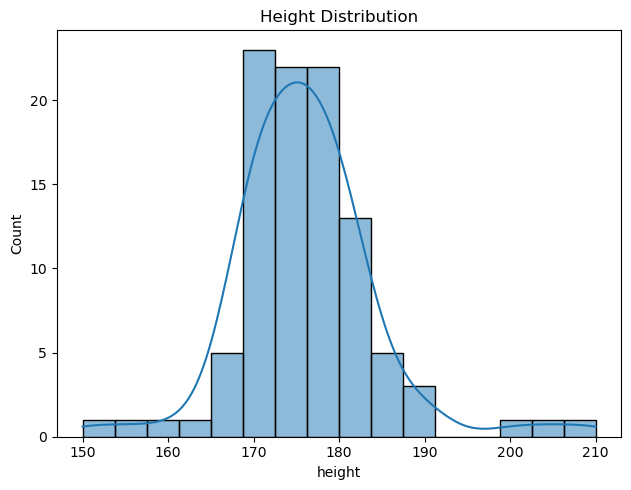

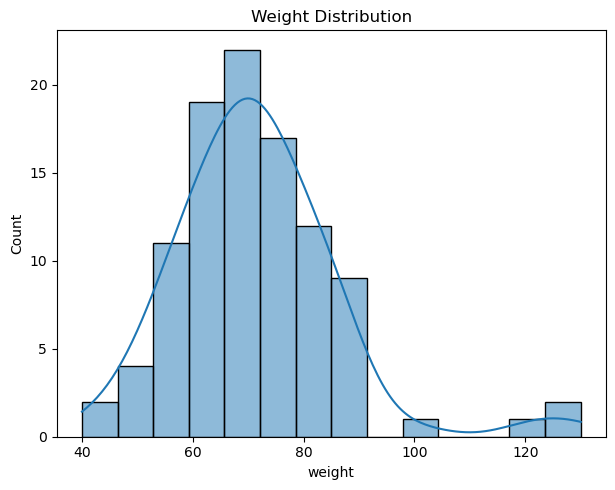

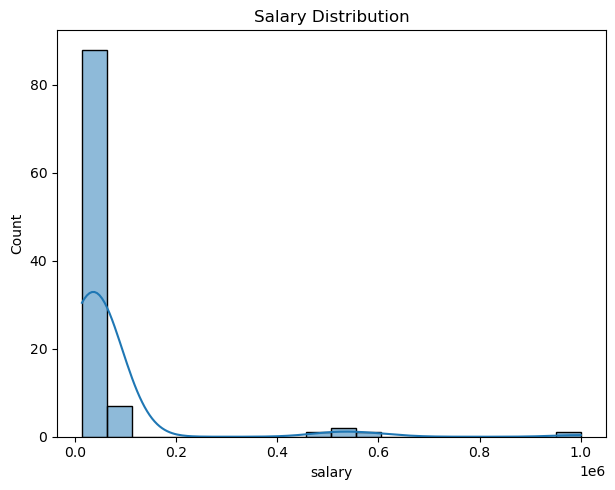

In [45]:
# Visualize distributions to identify potential outliers. 
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.histplot(x=df['height'], kde=True)
plt.title('Height Distribution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(18,5))
plt.subplot(1,3,2)
sns.histplot(x=df['weight'], kde=True)
plt.title('Weight Distribution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(18,5))
plt.subplot(1,3,3)
sns.histplot(x=df['salary'], kde=True)
plt.title('Salary Distribution')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Salary Box Plot')

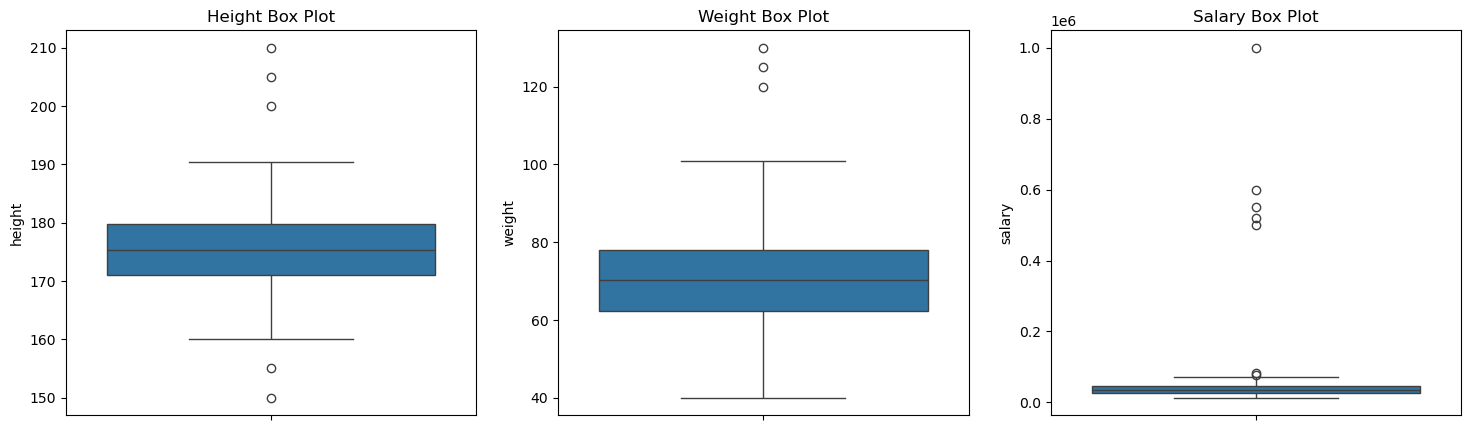

In [49]:
# Box plots to visualize potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['weight'])
plt.title('Weight Box Plot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['salary'])
plt.title('Salary Box Plot')

# plt.tight_layout()
# plt.show()

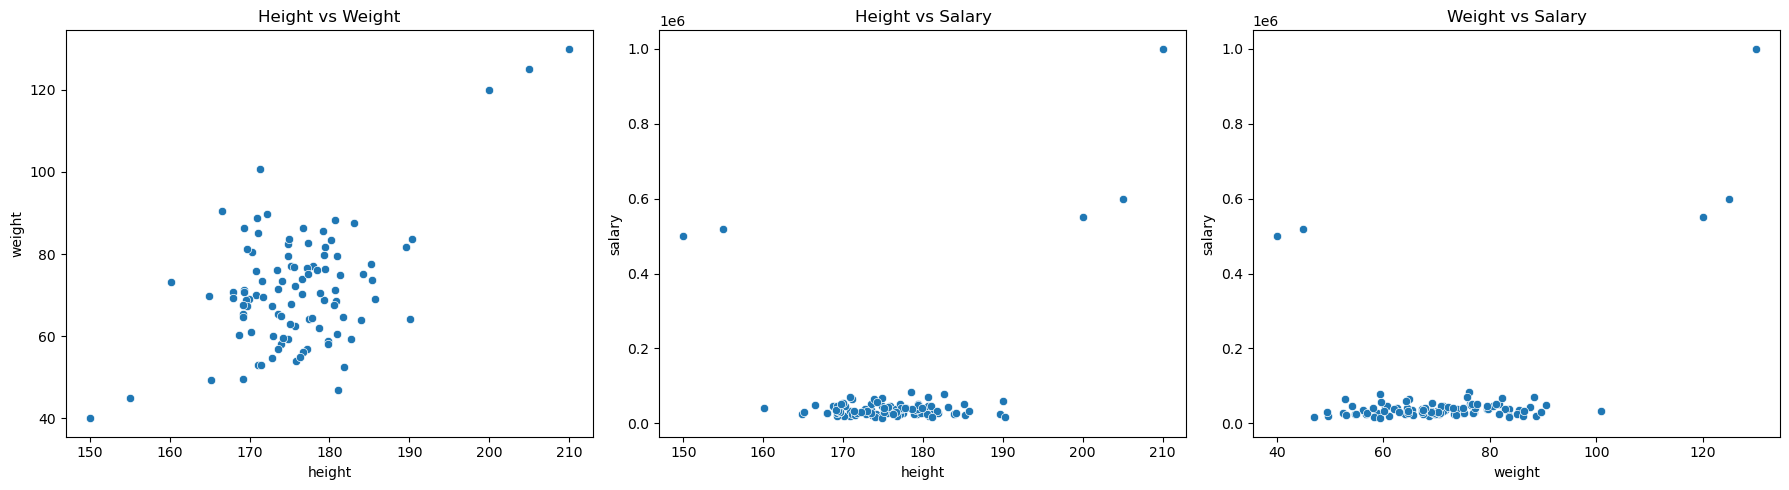

In [50]:
# Scatter plots to identify patterns and potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='height', y='weight', data=df)
plt.title('Height vs Weight')

plt.subplot(1, 3, 2)
sns.scatterplot(x='height', y='salary', data=df)
plt.title('Height vs Salary')

plt.subplot(1, 3, 3)
sns.scatterplot(x='weight', y='salary', data=df)
plt.title('Weight vs Salary')

plt.tight_layout()
plt.show()

In [53]:
# Define function for Z-Score outlier detection : 
def detect_outliers_zscore(data, threshold=3) : 
    """
    Detect outliers using Z-score method
    Returns indices of outliers
    """
    z_scores = np.abs(stats.zscore(data))
    return np.where(z_scores > threshold)[0]

In [63]:
# Apply z-score outlier detection : 
height_outliers_z = detect_outliers_zscore(df['height'])
weight_outliers_z = detect_outliers_zscore(df['weight'])
salary_outliers_z = detect_outliers_zscore(df['salary'])

print(f"Height outliers (Z-score) : {len(height_outliers_z)} found at indices {height_outliers_z}")
print(f"Weight outliers (Z-score) : {len(weight_outliers_z)} found at indices {weight_outliers_z}")
print(f"Salary outliers (Z-score) : {len(salary_outliers_z)} found at indices {salary_outliers_z}")

Height outliers (Z-score) : 3 found at indices [95 98 99]
Weight outliers (Z-score) : 3 found at indices [97 98 99]
Salary outliers (Z-score) : 5 found at indices [95 96 97 98 99]


In [64]:
# Defining and outlier using IQR method :  
def detect_outliers_iqr(data, factor=1.5) : 
    """
    Detect outliers using IQR method
    Returns indices of outliers
    """
    q1,q3 = np.percentile(data,[25,75])
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return np.where((data < lower_bound) | (data > upper_bound))[0]

In [65]:
# Apply IQR outlier detection
height_outliers_iqr = detect_outliers_iqr(df['height'])
weight_outliers_iqr = detect_outliers_iqr(df['weight'])
salary_outliers_iqr = detect_outliers_iqr(df['salary'])

print(f"Height outliers (IQR) are : {len(height_outliers_iqr)} found at indices : {height_outliers_iqr}")
print(f"Weight outliers (IQR) are : {len(weight_outliers_iqr)} found at indices : {weight_outliers_iqr}")
print(f"Salary outliers (IQR) are : {len(salary_outliers_iqr)} found at indices : {salary_outliers_iqr}")

Height outliers (IQR) are : 5 found at indices : [95 96 97 98 99]
Weight outliers (IQR) are : 3 found at indices : [97 98 99]
Salary outliers (IQR) are : 7 found at indices : [21 81 95 96 97 98 99]


Text(0.5, 1.0, 'Height Box Plot')

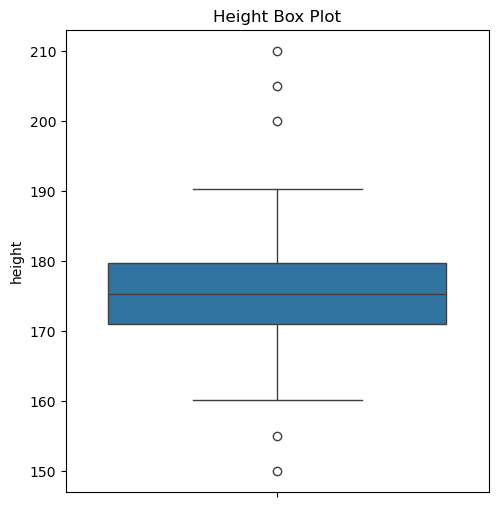

In [104]:
# Visualize the detected outliers for height using box plot with highlighted outliers

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')

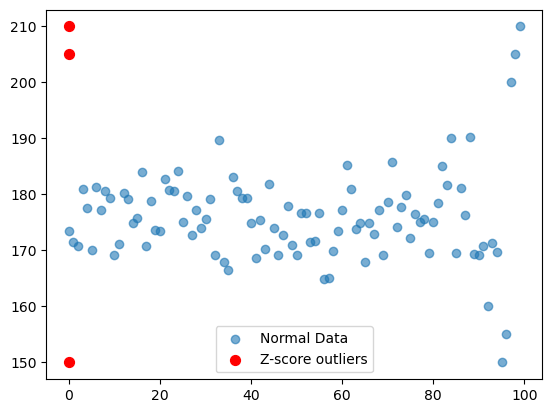

In [105]:
plt.scatter(range(len(df)), df['height'], alpha=0.6, label='Normal Data')
plt.scatter(np.zeros_like(height_outliers_z), df['height'].iloc[height_outliers_z], color='red', s=50, label='Z-score outliers')
plt.legend()

Text(0.5, 1.0, 'Weight Box Plot')

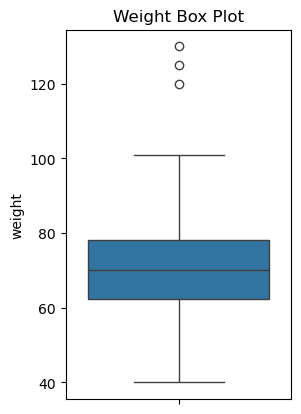

In [107]:
plt.subplot(1,2,2)
sns.boxplot(y=df['weight'])
plt.title('Weight Box Plot')

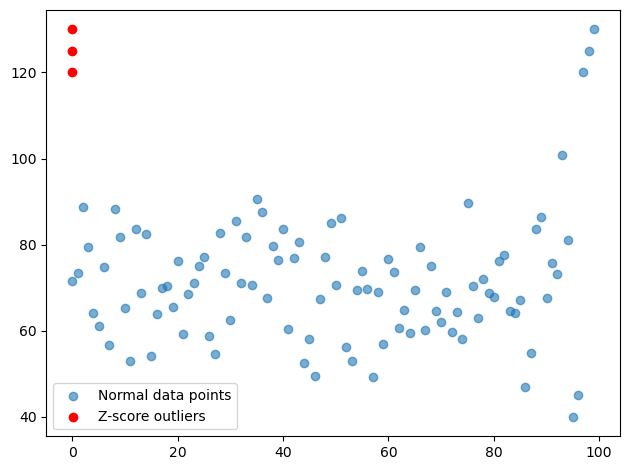

In [121]:
plt.scatter(range(len(df)), df['weight'], label='Normal data points', alpha=0.6)
plt.scatter(np.zeros_like(weight_outliers_z), df['weight'].iloc[weight_outliers_z], color='red', label='Z-score outliers')
plt.legend()
plt.tight_layout()
plt.show()

In [124]:
# Examining the impact of outliers on statistical measures
print('With Outliers : ')
print(f"Height mean : {df['height'].mean():.2f}, std : {df['height'].std():.2f}")
print(f"Weight mean : {df['weight'].mean():.2f}, std : {df['weight'].std():.2f}")
print(f"Salary mean : {df['salary'].mean():.2f}, std : {df['salary'].std():.2f}")

With Outliers : 
Height mean : 176.03, std : 8.28
Weight mean : 71.43, std : 14.74
Salary mean : 66303.21, std : 138116.12


In [132]:
# Create copies without outliers (using IQR method)
df_no_outliers = df.copy()
all_outliers = list(set(height_outliers_iqr) | set(weight_outliers_iqr) | set(salary_outliers_iqr))
df_no_outliers = df_no_outliers.drop(all_outliers).reset_index(drop=True)

print("\nWithout outliers:")
print(f"Height mean: {df_no_outliers['height'].mean():.2f}, std: {df_no_outliers['height'].std():.2f}")
print(f"Weight mean: {df_no_outliers['weight'].mean():.2f}, std: {df_no_outliers['weight'].std():.2f}")
print(f"Salary mean: {df_no_outliers['salary'].mean():.2f}, std: {df_no_outliers['salary'].std():.2f}")


Without outliers:
Height mean: 175.50, std: 5.73
Weight mean: 70.40, std: 10.88
Salary mean: 35473.97, std: 12852.22


In [135]:
# Handling outliers using different approaches
# 1. Removal (already done above)
# 2. Capping (Winsorization)

def winsorize(data, limits=(0.05,0.05)) : 
    """Apply winsorization to limit extreme values"""
    lower_limit = np.percentile(data, limits[0] * 100)
    upper_limit = np.percentile(data, 100 - limits[1] * 100)
    return np.clip(data, lower_limit, upper_limit)

df_winsorized = df.copy()
df_winsorized['height'] = winsorize(df['height'])
df_winsorized['weight'] = winsorize(df['weight'])
df_winsorized['salary'] = winsorize(df['salary'])

In [146]:
# Log Transformation (especially useful for skewed data like salary)
df_log = df.copy()
# df['salary']
df_log['salary'] = np.log(df['salary'])
df_log['salary']

0     10.448833
1     10.117784
2      9.857421
3     10.581385
4     10.197460
        ...    
95    13.122363
96    13.161584
97    13.217674
98    13.304685
99    13.815511
Name: salary, Length: 100, dtype: float64

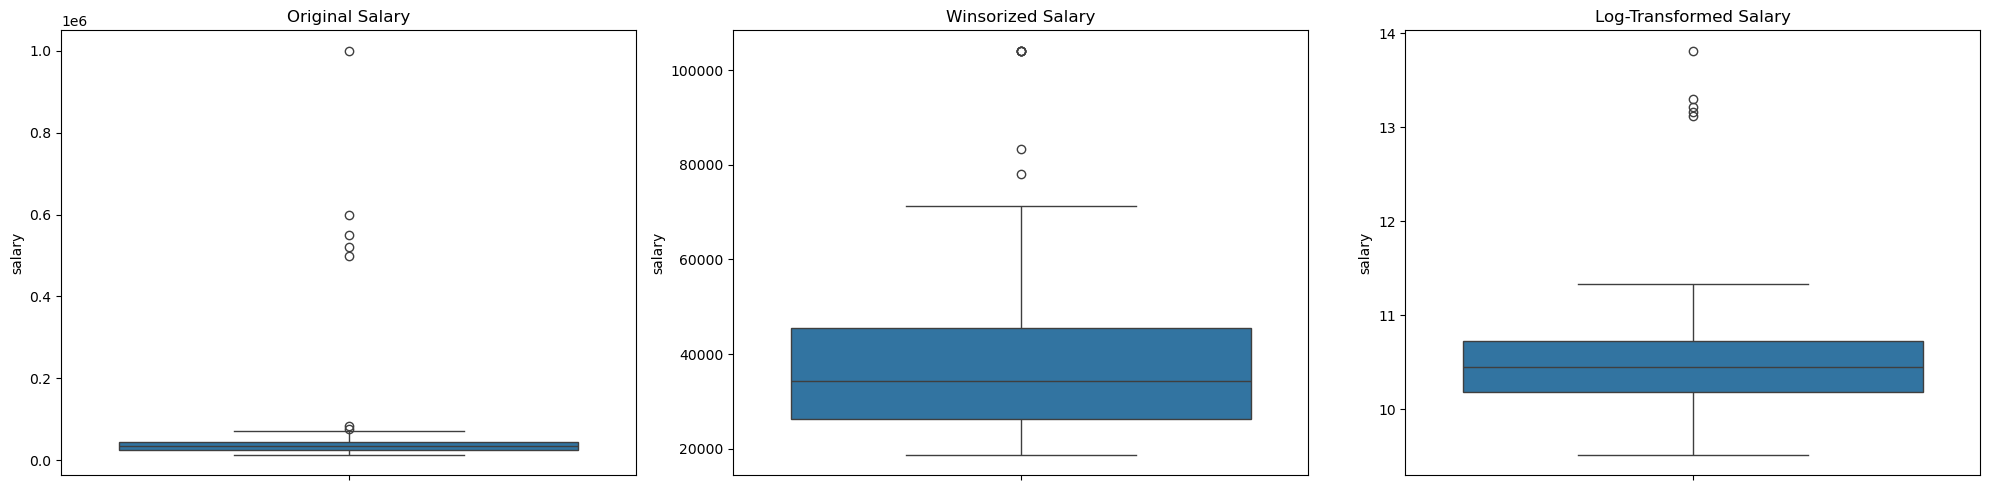

In [148]:
# Compare the distributions before and after transformation
plt.figure(figsize=(20, 5))

# Original distributions
plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

# After winsorization
plt.subplot(1, 3, 2)
sns.boxplot(y=df_winsorized['salary'])
plt.title('Winsorized Salary')

# After log transformation
plt.subplot(1, 3, 3)
sns.boxplot(y=df_log['salary'])
plt.title('Log-Transformed Salary')

plt.tight_layout()
plt.show()

In [149]:
# Feature associations and correlation analysis
# Calculate correlation matrix
corr_matrix = df.corr()

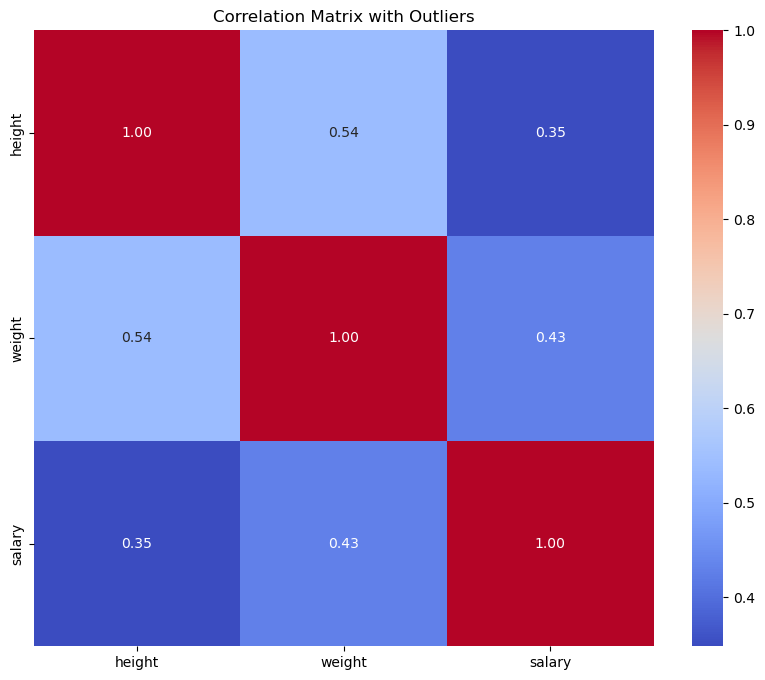

In [150]:
# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix with Outliers')
plt.show()

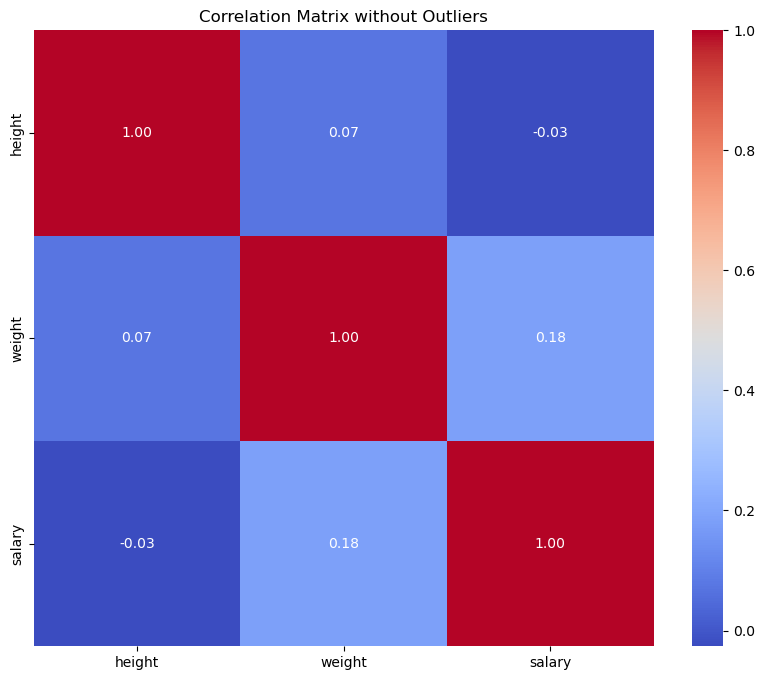

In [151]:
# Compare with correlation after removing outliers
corr_matrix_no_outliers = df_no_outliers.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_no_outliers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix without Outliers')
plt.show()

In [152]:
# Create function to profile features and detect potential issues
def profile_feature(data, feature_name):
    """Create a basic profile of a numeric feature"""
    feature = data[feature_name]

    # Basic statistics
    stats_dict = {
        'Count': len(feature),
        'Mean': feature.mean(),
        'Median': feature.median(),
        'Std Dev': feature.std(),
        'Min': feature.min(),
        'Max': feature.max(),
        'Range': feature.max() - feature.min(),
        'IQR': np.percentile(feature, 75) - np.percentile(feature, 25),
        'Skewness': stats.skew(feature),
        'Kurtosis': stats.kurtosis(feature),
        'Missing Values': feature.isna().sum(),
        'Missing %': feature.isna().mean() * 100
    }

    # Z-score outliers
    z_outliers = detect_outliers_zscore(feature)
    stats_dict['Z-score Outliers'] = len(z_outliers)
    stats_dict['Z-score Outlier %'] = len(z_outliers) / len(feature) * 100

    # IQR outliers
    iqr_outliers = detect_outliers_iqr(feature)
    stats_dict['IQR Outliers'] = len(iqr_outliers)
    stats_dict['IQR Outlier %'] = len(iqr_outliers) / len(feature) * 100

    return pd.Series(stats_dict, name=feature_name)


In [153]:
# Apply feature profiling to the dataset
profile_results = pd.DataFrame([
    profile_feature(df, 'height'),
    profile_feature(df, 'weight'),
    profile_feature(df, 'salary')
])

# Display the feature profiles
profile_results

,Count,Mean,Median,Std Dev,Min,Max,Range,IQR,Skewness,Kurtosis,Missing Values,Missing %,Z-score Outliers,Z-score Outlier %,IQR Outliers,IQR Outlier %
height,100.0,176.026504,175.351102,8.275682,150.000000,210.0,60.000000,8.778947,0.906895,4.228779,0.0,0.0,3.0,3.0,5.0,5.0
weight,100.0,71.428070,70.202536,14.738939,40.000000,130.0,90.000000,15.653199,1.260769,3.576726,0.0,0.0,3.0,3.0,3.0,3.0
salary,100.0,66303.213974,34313.579085,138116.118882,13512.118115,1000000.0,986487.881885,19208.092220,4.817059,24.303559,0.0,0.0,5.0,5.0,7.0,7.0


In [154]:
# Fixed function for multivariate outlier detection
def detect_multivariate_outliers(data, method='mahalanobis', threshold=0.99):
    """
    Detect multivariate outliers using Mahalanobis distance
    Returns indices of outliers
    """
    if method == 'mahalanobis':
        # Calculate Mahalanobis distance
        x = data.values
        covariance_matrix = np.cov(x, rowvar=False)
        inv_covariance_matrix = np.linalg.inv(covariance_matrix)
        mean_vector = np.mean(x, axis=0)

        # Implement mahalanobis distance manually
        mahalanobis_dist = []
        for i in range(x.shape[0]):
            x_i = x[i, :]
            # Calculate mahalanobis distance: (x-μ)ᵀΣ⁻¹(x-μ)
            diff = x_i - mean_vector
            mahal = np.sqrt(diff.dot(inv_covariance_matrix).dot(diff.T))
            mahalanobis_dist.append(mahal)

        # Convert to array
        mahalanobis_dist = np.array(mahalanobis_dist)

        # Find threshold using chi-squared distribution
        threshold_value = stats.chi2.ppf(threshold, df=x.shape[1])

        # Return indices of outliers
        return np.where(mahalanobis_dist > threshold_value)[0]
    else:
        raise ValueError("Only 'mahalanobis' method is currently supported")


In [155]:
# Apply multivariate outlier detection
multivariate_outliers = detect_multivariate_outliers(df, threshold=0.95)
print(f"Multivariate outliers: {len(multivariate_outliers)} found at indices {multivariate_outliers}")

Multivariate outliers: 0 found at indices []


<Figure size 1200x1000 with 0 Axes>

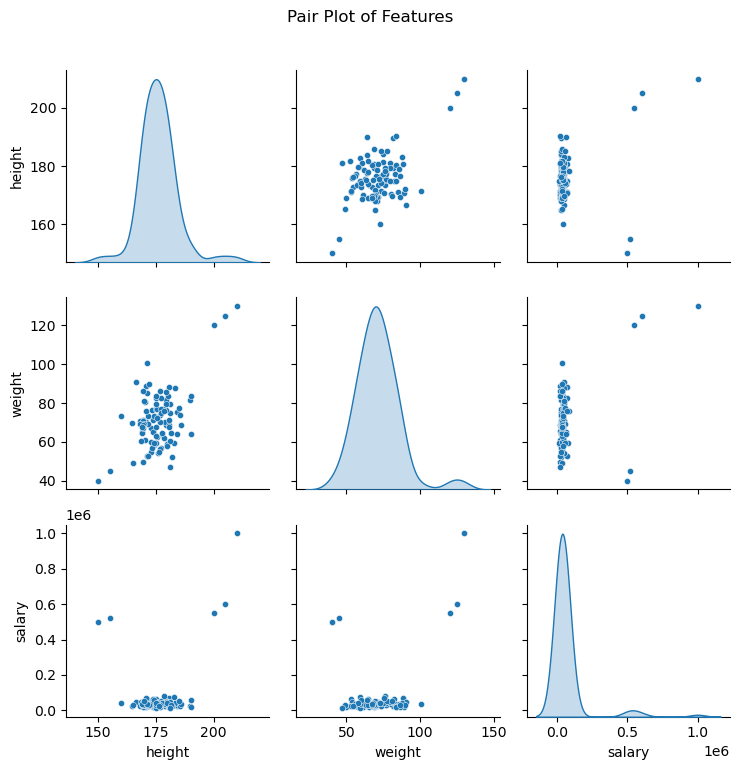

In [156]:
# Visualize the multivariate outliers in a pair plot
plt.figure(figsize=(12, 10))
sns.pairplot(df, diag_kind='kde', plot_kws={"s": 20})
plt.suptitle('Pair Plot of Features', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\hi\AppData\Local\Temp\ipykernel_19416\3117540217.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


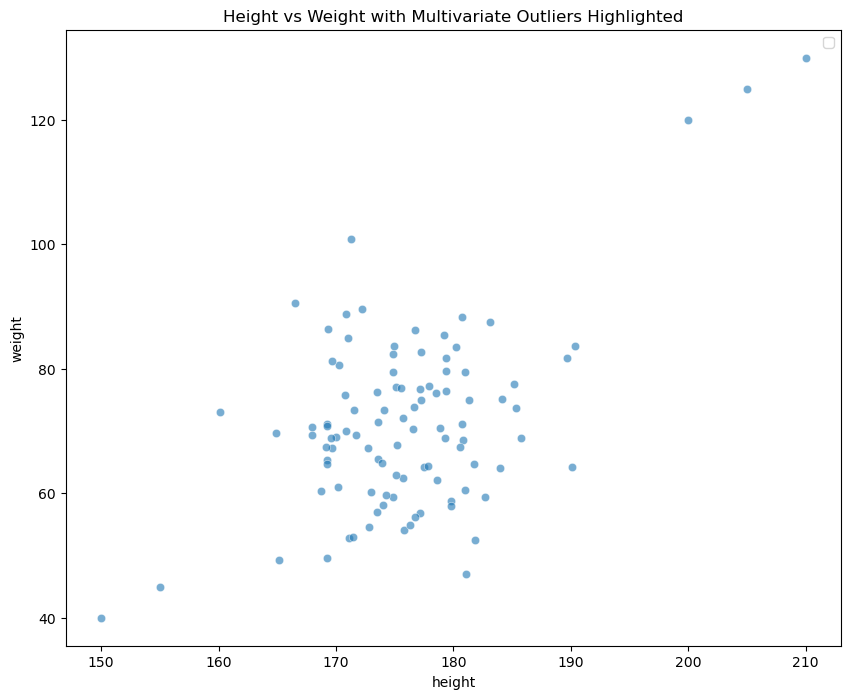

In [159]:
# Highlight the multivariate outliers in a scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='height', y='weight', data=df, alpha=0.6)
sns.scatterplot(x='height', y='weight', data=df.iloc[multivariate_outliers],
                color='red', s=100, label='Multivariate Outliers')
plt.title('Height vs Weight with Multivariate Outliers Highlighted')
plt.legend()
plt.show()


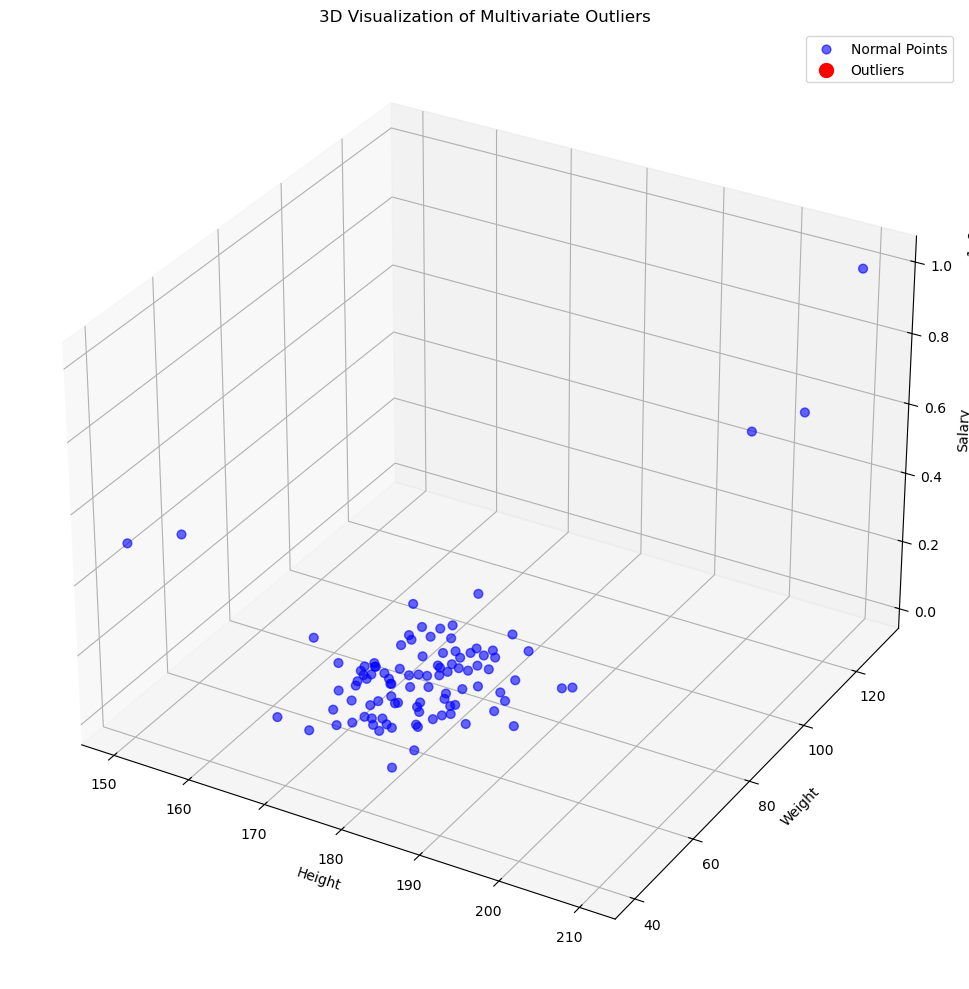

In [165]:
# 3D visualization of outliers
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Regular points
ax.scatter(df['height'], df['weight'], df['salary'], c='blue', s=40, alpha=0.6, label='Normal Points')
# Outliers
ax.scatter(df.iloc[multivariate_outliers]['height'], df.iloc[multivariate_outliers]['weight'],
           df.iloc[multivariate_outliers]['salary'], c='red', s=100, label='Outliers')

ax.set_xlabel('Height')
ax.set_ylabel('Weight')
ax.set_zlabel('Salary')
ax.set_title('3D Visualization of Multivariate Outliers')
plt.legend()
plt.tight_layout()
plt.show()

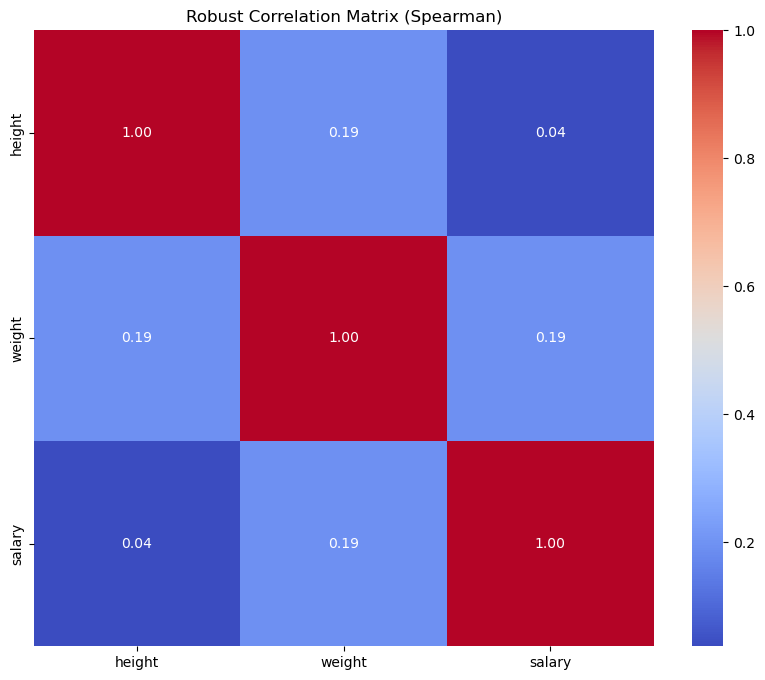

In [166]:
# Simple robust correlation calculation using Spearman instead of Pearson
robust_corr = df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(robust_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Robust Correlation Matrix (Spearman)')
plt.show()

In [171]:
# Apply different scaling methods before and after outlier treatment
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

In [172]:
# Original data
scaler_standard = StandardScaler()
df_scaled_standard = pd.DataFrame(
    scaler_standard.fit_transform(df),
    columns=df.columns
)

In [173]:
# Using robust scaler which is less influenced by outliers
scaler_robust = RobustScaler()
df_scaled_robust = pd.DataFrame(
    scaler_robust.fit_transform(df),
    columns=df.columns
)

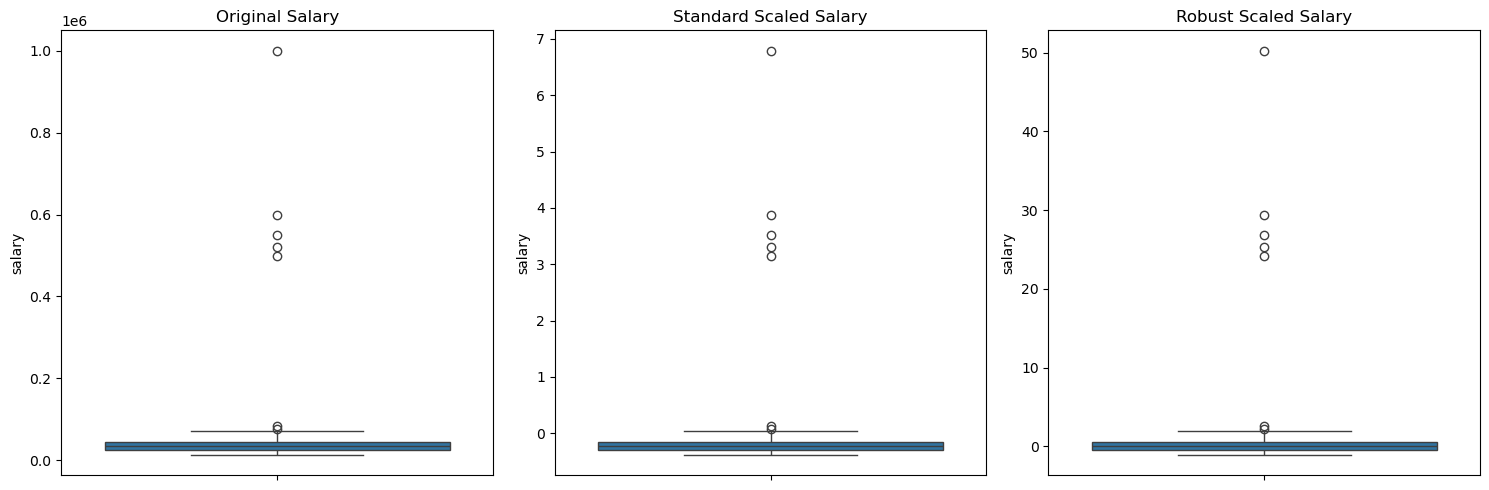

In [174]:
# Compare the scaled distributions
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_scaled_standard['salary'])
plt.title('Standard Scaled Salary')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_scaled_robust['salary'])
plt.title('Robust Scaled Salary')

plt.tight_layout()
plt.show()


In [175]:
# Demonstrate impact of outliers on linear regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [176]:
# Create dataset with outlier
x = np.array(range(20)).reshape(-1, 1)
y = 2*x.ravel() + 5 + np.random.normal(0, 1, 20)
y[19] = 80  # add outlier

plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'With Outlier: y = 2.55x + 1.70')

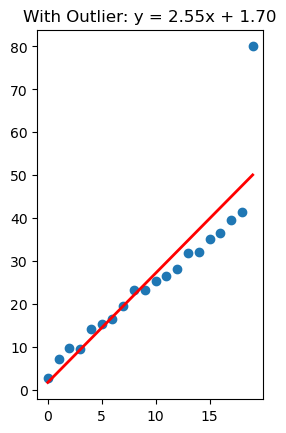

In [177]:
# Plot with outlier
plt.subplot(1, 2, 1)
plt.scatter(x, y)
model = LinearRegression().fit(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'With Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

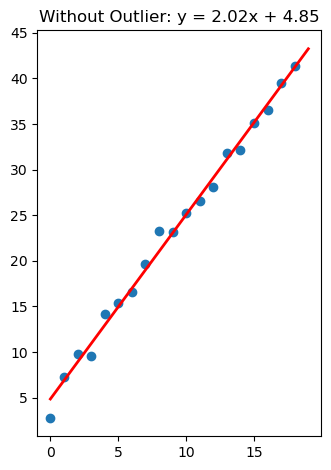

In [178]:
# Plot without outlier
plt.subplot(1, 2, 2)
plt.scatter(x[:-1], y[:-1])
model = LinearRegression().fit(x[:-1], y[:-1])
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'Without Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

plt.tight_layout()
plt.show()

# Interactive Coding Exercise: Advanced Outlier Detection & Analysis

In [179]:
# ----------------------------------------------------------------
# In this exercise, you'll work with a real-world dataset to:
# 1. Apply outlier detection techniques
# 2. Compare methods and their impact
# 3. Implement a custom outlier detection workflow

In [191]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the california housing dataset instead of Boston
from sklearn.datasets import fetch_california_housing

# Load the Dataset
housing = fetch_california_housing() 
X =  pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Create a DataFrame with all features plus the target
df = X.copy()
df['MedHouseVal'] = y  # The target is median house value

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFeature names:", list(X.columns))
print("\nFirst 5 rows:")
df.head()

Dataset shape: (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# EXERCISE 1: Exploratory Data Analysis for Outlier Detection
# -----------------------------------------------------------
# TODO: Create histograms and boxplots for at least 3 features to visually identify outliers
# Hint: Use subplot to organize multiple plots


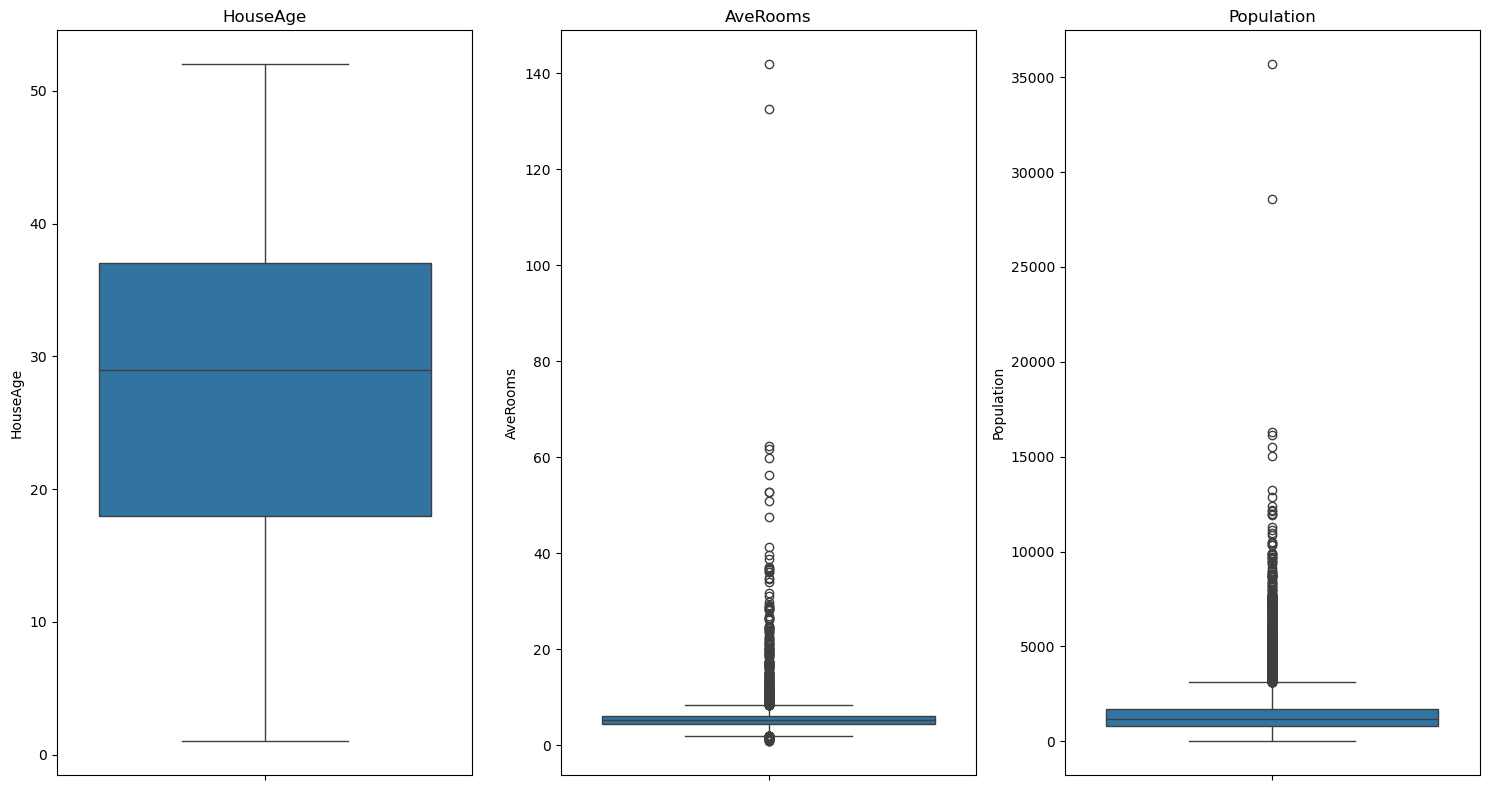

In [218]:
plt.figure(figsize=(15,8))
plt.subplot(1,3,1)
sns.boxplot(y=df['HouseAge'])
plt.title('HouseAge')

plt.subplot(1,3,2)
sns.boxplot(y=df['AveRooms'])
plt.title('AveRooms')

plt.subplot(1,3,3)
sns.boxplot(y=df['Population'])
plt.title('Population')

plt.tight_layout()
plt.show()

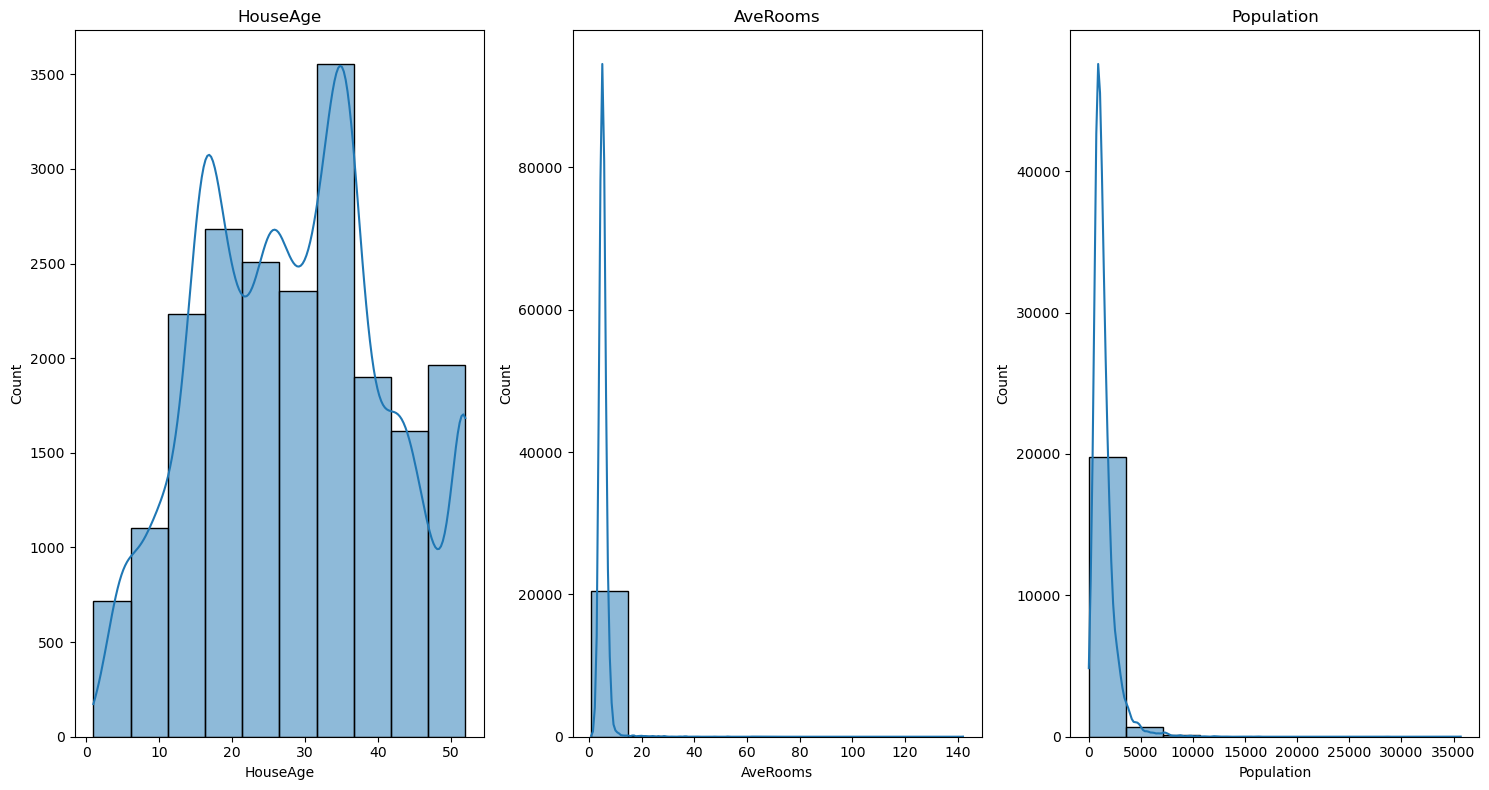

In [228]:
plt.figure(figsize=(15,8))

plt.subplot(1,3,1)
sns.histplot(x=df['HouseAge'],kde=True, bins=10)
plt.title('HouseAge')

plt.subplot(1,3,2)
sns.histplot(x=df['AveRooms'],kde=True,bins=10)
plt.title('AveRooms')

plt.subplot(1,3,3)
sns.histplot(x=df['Population'],kde=True, bins=10)
plt.title('Population')

plt.tight_layout()
plt.show()

# EXERCISE 2: Implement Multiple Outlier Detection Methods
# -------------------------------------------------------
# TODO: Implement both Z-score and IQR outlier detection for the medhousevalue(last col) feature
# medhousevalue(last col): % lower status of the population

In [243]:
# Outlier detection using z-score : 
z_scores = np.abs(stats.zscore(df['MedHouseVal']))
z_threshold = 3

outliers_z = df[z_scores > z_threshold]
print(f"No of Outlier Detected : {len(outliers_z)}")
print(f"Percentage of outliers : {len(outliers_z)/len(df)*100:.2f}%")

No of Outlier Detected : 0
Percentage of outliers : 0.00%


In [246]:
# Outlier detection using IQR : 

q1, q3 = np.percentile(df['MedHouseVal'], [25, 75])
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr


outliers_iqr = df[(df['MedHouseVal'] < lower_bound) | (df['MedHouseVal'] > upper_bound)]
print(f"\nIQR method: {len(outliers_iqr)} outliers detected")
print(f"Outlier percentage: {len(outliers_iqr)/len(df)*100:.2f}%")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

# ----- Compare the two methods -----
print(f"\nComparison:")
print(f"Z-score flagged: {len(outliers_z)} points")
print(f"IQR flagged: {len(outliers_iqr)} points")


IQR method: 1071 outliers detected
Outlier percentage: 5.19%
Lower bound: -0.98, Upper bound: 4.82

Comparison:
Z-score flagged: 0 points
IQR flagged: 1071 points


# EXERCISE 3: Advanced Outlier Detection - Isolation Forest
# --------------------------------------------------------
# TODO: Implement the Isolation Forest algorithm to detect outliers in the dataset
# Use contamination=0.05 (assuming 5% of data points are outliers)
# Return a binary mask where -1 represents outliers


In [251]:
# EXERCISE 3: Advanced Outlier Detection - Isolation Forest
# --------------------------------------------------------

# Initialize the Isolation Forest model
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# Fit the model and predict outliers
# fit_predict returns 1 for inliers, -1 for outliers
outlier_mask = iso_forest.fit_predict(df)

# Creating a separate column here : 
df['outlier_iforest'] = outlier_mask

# Separate outliers and inliers
outliers_iforest = df[df['outlier_iforest'] == -1]
inliers_iforest = df[df['outlier_iforest'] == 1]

print(f"Isolation Forest: {len(outliers_iforest)} outliers detected")
print(f"Outlier percentage: {len(outliers_iforest)/len(df)*100:.2f}%")
print(outliers_iforest.head())

Isolation Forest: 1032 outliers detected
Outlier percentage: 5.00%
    MedInc  HouseAge  AveRooms  AveBedrms  Population   AveOccup  Latitude  \
59  2.5625       2.0  2.771930   0.754386        94.0   1.649123     37.82   
63  1.1910      52.0  7.698113   1.490566       521.0   3.276730     37.81   
73  0.4999      46.0  1.714286   0.571429        18.0   2.571429     37.81   
89  1.2434      52.0  2.929412   0.917647       396.0   4.658824     37.80   
91  0.8668      52.0  2.443182   0.988636       904.0  10.272727     37.80   

    Longitude  MedHouseVal  outlier_iforest  
59    -122.29      0.60000               -1  
63    -122.30      0.76100               -1  
73    -122.29      0.67500               -1  
89    -122.27      5.00001               -1  
91    -122.28      1.37500               -1  


# EXERCISE 4: Compare the Impact of Outliers on Linear Regression
# --------------------------------------------------------------
# TODO:
# 1. Create a simple linear regression model using 'medinc' to predict 'medhouse value'
# 2. Create 3 versions:
#    a. With all data
#    b. After removing Z-score outliers
#    c. After removing Isolation Forest outliers
# 3. Compare the model performance metrics (r2_score) and coefficients


In [253]:
# EXERCISE: Linear Regression - Comparing Outlier Removal Methods
# -----------------------------------------------------------------

# ----- Step 1 & 2a: Model WITH ALL DATA -----
X_all = df[['MedInc']]
y_all = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

model_all = LinearRegression()
model_all.fit(X_train, y_train)
y_pred_all = model_all.predict(X_test)

r2_all = r2_score(y_test, y_pred_all)
coef_all = model_all.coef_[0]

print("Model A: All Data")
print(f"R2 Score: {r2_all:.4f}")
print(f"Coefficient (MedInc): {coef_all:.4f}")
print(f"Intercept: {model_all.intercept_:.4f}\n")


# ----- Step 2b: Model AFTER REMOVING Z-SCORE OUTLIERS -----
z_scores = np.abs(stats.zscore(df['MedHouseVal']))
df_z_clean = df[z_scores <= 3]   # keep only non-outliers

X_z = df_z_clean[['MedInc']]
y_z = df_z_clean['MedHouseVal']

X_train_z, X_test_z, y_train_z, y_test_z = train_test_split(X_z, y_z, test_size=0.2, random_state=42)

model_z = LinearRegression()
model_z.fit(X_train_z, y_train_z)
y_pred_z = model_z.predict(X_test_z)

r2_z = r2_score(y_test_z, y_pred_z)
coef_z = model_z.coef_[0]

print("Model B: Z-score Outliers Removed")
print(f"Rows remaining: {len(df_z_clean)} (removed {len(df) - len(df_z_clean)})")
print(f"R2 Score: {r2_z:.4f}")
print(f"Coefficient (MedInc): {coef_z:.4f}")
print(f"Intercept: {model_z.intercept_:.4f}\n")


# ----- Step 2c: Model AFTER REMOVING ISOLATION FOREST OUTLIERS -----
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_mask = iso_forest.fit_predict(df[['MedInc', 'MedHouseVal']])

df_iforest_clean = df[outlier_mask == 1]   # keep only inliers (label == 1)

X_if = df_iforest_clean[['MedInc']]
y_if = df_iforest_clean['MedHouseVal']

X_train_if, X_test_if, y_train_if, y_test_if = train_test_split(X_if, y_if, test_size=0.2, random_state=42)

model_if = LinearRegression()
model_if.fit(X_train_if, y_train_if)
y_pred_if = model_if.predict(X_test_if)

r2_if = r2_score(y_test_if, y_pred_if)
coef_if = model_if.coef_[0]

print("Model C: Isolation Forest Outliers Removed")
print(f"Rows remaining: {len(df_iforest_clean)} (removed {len(df) - len(df_iforest_clean)})")
print(f"R2 Score: {r2_if:.4f}")
print(f"Coefficient (MedInc): {coef_if:.4f}")
print(f"Intercept: {model_if.intercept_:.4f}\n")


# ----- Step 3: Compare all three -----
comparison = pd.DataFrame({
    'Model': ['All Data', 'Z-score Cleaned', 'Isolation Forest Cleaned'],
    'R2 Score': [r2_all, r2_z, r2_if],
    'Coefficient': [coef_all, coef_z, coef_if],
    'Rows Used': [len(df), len(df_z_clean), len(df_iforest_clean)]
})

print("Comparison Table:")
print(comparison)

Model A: All Data
R2 Score: 0.4589
Coefficient (MedInc): 0.4193
Intercept: 0.4446

Model B: Z-score Outliers Removed
Rows remaining: 20640 (removed 0)
R2 Score: 0.4589
Coefficient (MedInc): 0.4193
Intercept: 0.4446

Model C: Isolation Forest Outliers Removed
Rows remaining: 19608 (removed 1032)
R2 Score: 0.4492
Coefficient (MedInc): 0.4713
Intercept: 0.2247

Comparison Table:
                      Model  R2 Score  Coefficient  Rows Used
0                  All Data  0.458859     0.419338      20640
1           Z-score Cleaned  0.458859     0.419338      20640
2  Isolation Forest Cleaned  0.449206     0.471251      19608


# EXERCISE 5: Create Your Own Outlier Detection Workflow
# -----------------------------------------------------
# TODO: Create a custom outlier detection function that combines multiple methods
# It should:
# 1. Take a dataframe and column name as input
# 2. Apply at least 2 different outlier detection methods (of your choice)
# 3. Return the indices of consensus outliers (detected by both methods)
# 4. Include a visualization of the outliers

Z-score outliers detected: 0
IQR outliers detected: 1071
Consensus outliers: 0
[]


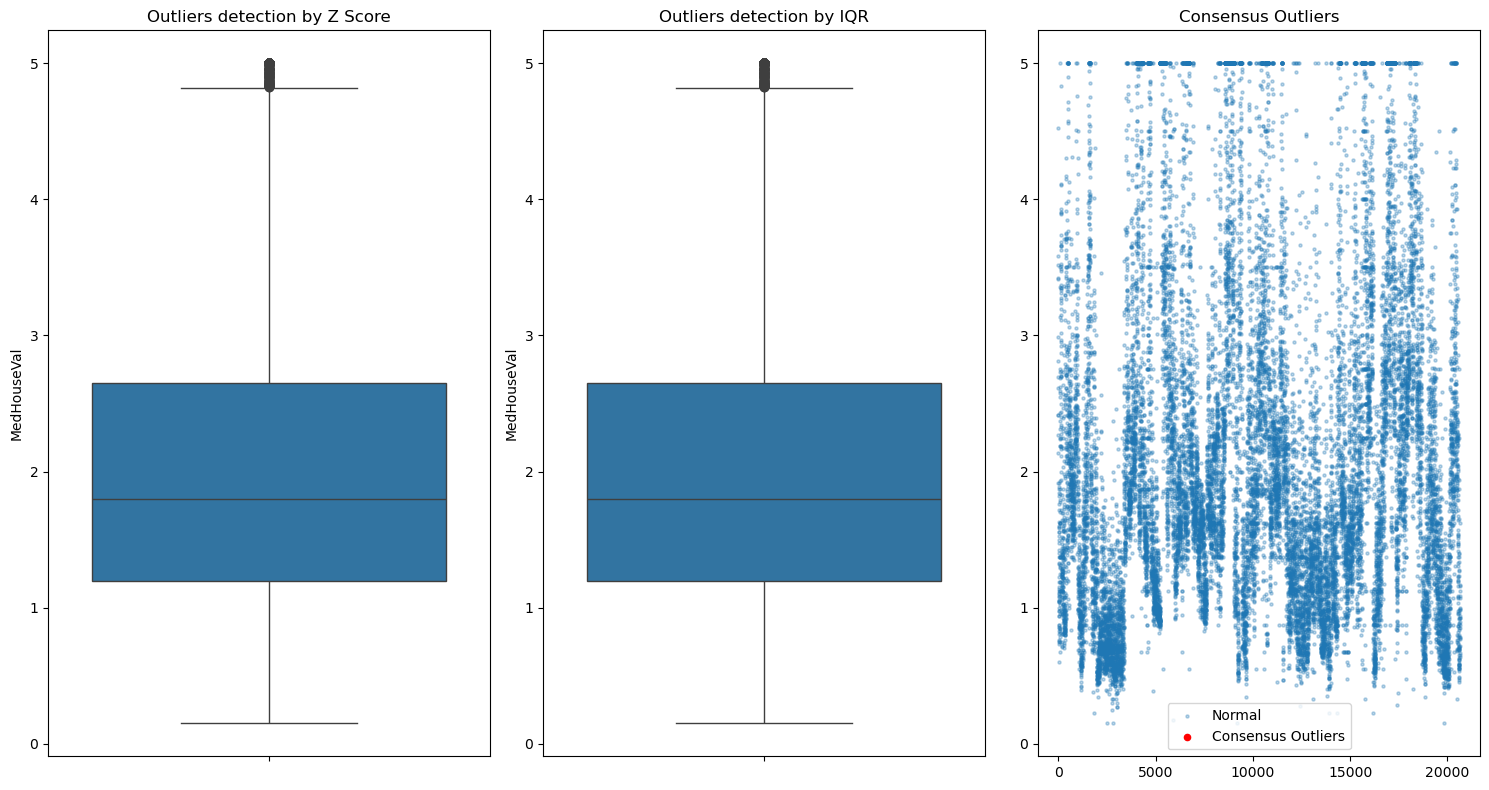

In [331]:
plt.figure(figsize=(15,8))
def outlier_workflow(data, col):
    # Method 1: Z-score
    z_scores = np.abs(stats.zscore(data[col]))
    z_threshold = 3
    detected_outlier_z = np.where(z_scores > z_threshold)[0]
    print(f"Z-score outliers detected: {len(detected_outlier_z)}")

    # Method 2: IQR
    q1, q3 = np.percentile(data[col], [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)     # fixed
    detected_outlier_iqr = np.where((data[col] < lower_bound) | (data[col] > upper_bound))[0]
    print(f"IQR outliers detected: {len(detected_outlier_iqr)}")

    # Consensus: outliers flagged by BOTH methods
    consensus = np.intersect1d(detected_outlier_z, detected_outlier_iqr)
    print(f"Consensus outliers: {len(consensus)}")

    plt.subplot(1,3,1)
    sns.boxplot(y=data[col])
    plt.title('Outliers detection by Z Score')

    plt.subplot(1,3,2)
    sns.boxplot(y=data[col])
    plt.title('Outliers detection by IQR')

    # ----- Plot 3: Scatter highlighting consensus outliers -----
    plt.subplot(1, 3, 3)
    plt.scatter(range(len(data)), data[col], s=5, label='Normal', alpha=0.3)
    plt.scatter(consensus, data[col].iloc[consensus], color='red', s=20, label='Consensus Outliers')
    plt.title('Consensus Outliers')
    plt.legend()

    plt.tight_layout()

    
    
    return consensus


result = outlier_workflow(df, 'MedHouseVal')
print(result)

# EXERCISE 6: Robust Feature Engineering with Outliers
# ---------------------------------------------------
# TODO: Create a new feature that is more robust to outliers
# Suggestions:
# - Use log transformation
# - Use binning/discretization
# - Create a ratio or interaction feature
# Compare the distribution before and after your transformation


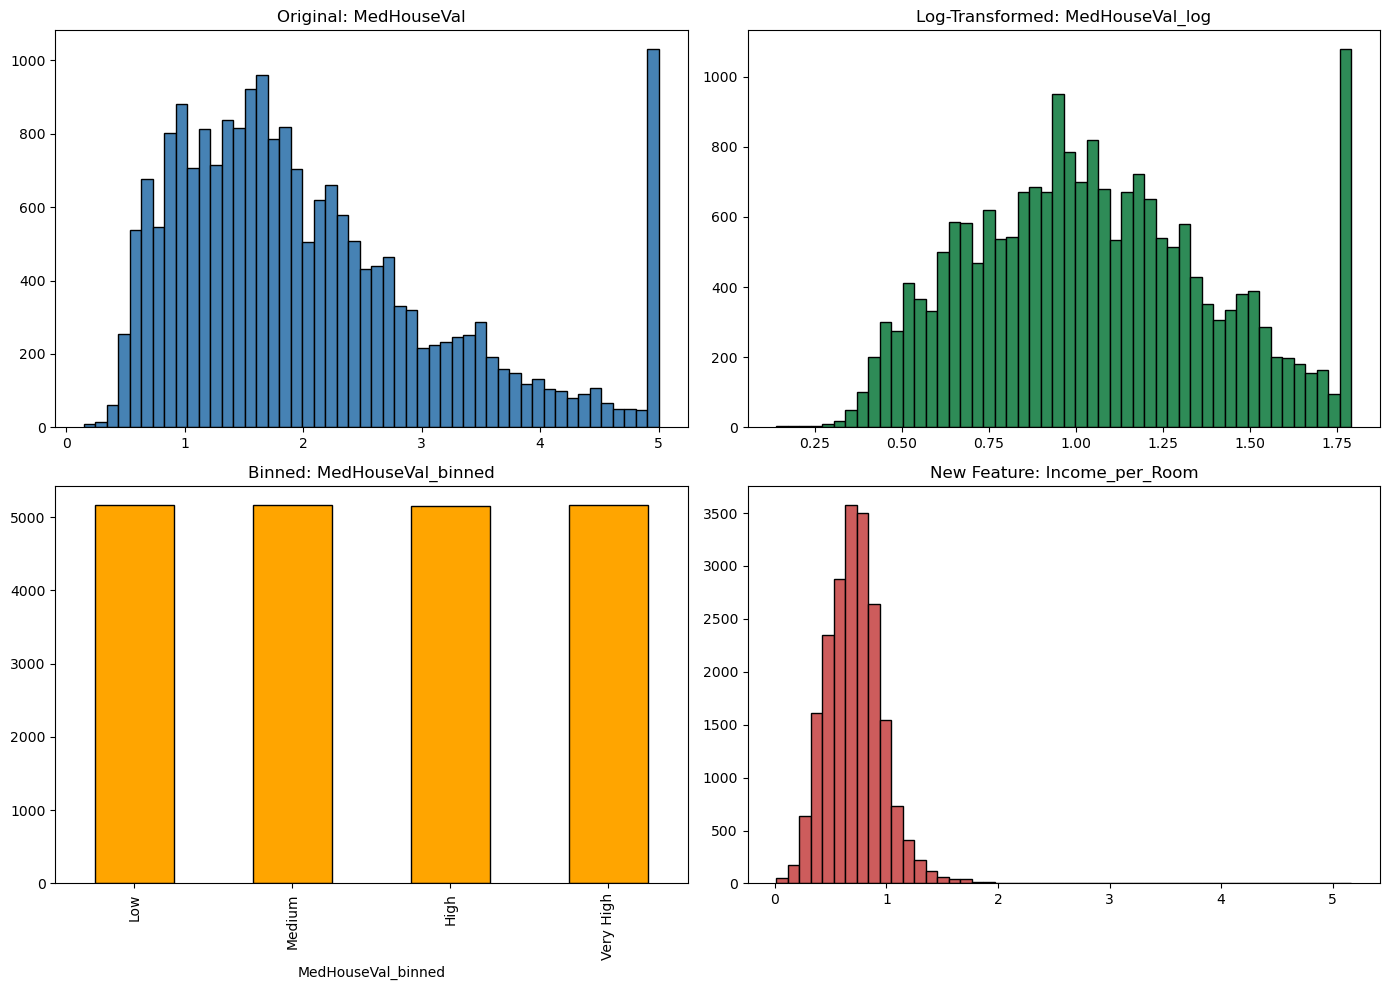

Skewness comparison:
Original MedHouseVal skewness: 0.9778
Log-transformed skewness: 0.2759
Income_per_Room skewness: 1.0777


In [332]:
# EXERCISE 6: Robust Feature Engineering with Outliers
# ---------------------------------------------------

# ----- Approach 1: Log Transformation -----
# Log transform compresses large values much more than small values,
# which reduces the influence of extreme outliers (right-skewed data especially).
df['MedHouseVal_log'] = np.log1p(df['MedHouseVal'])  # log1p = log(1 + x), handles zero values safely

# ----- Approach 2: Binning / Discretization -----
# Converts continuous values into categorical buckets (quartiles here).
# Outliers just fall into the "highest" or "lowest" bin instead of skewing calculations.
df['MedHouseVal_binned'] = pd.qcut(df['MedHouseVal'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

# ----- Approach 3: Ratio / Interaction Feature -----
# Combines two columns into a more stable, meaningful ratio.
# Example: Rooms per household (AveRooms is already a ratio, so let's make a new one)
# Income per room -> tells us how "expensive" each room is relative to income
df['Income_per_Room'] = df['MedInc'] / df['AveRooms']


# ----- Compare distributions BEFORE and AFTER transformation -----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original distribution
axes[0, 0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Original: MedHouseVal')

# Log-transformed distribution
axes[0, 1].hist(df['MedHouseVal_log'], bins=50, color='seagreen', edgecolor='black')
axes[0, 1].set_title('Log-Transformed: MedHouseVal_log')

# Binned distribution (value counts as bar chart)
df['MedHouseVal_binned'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='orange', edgecolor='black')
axes[1, 0].set_title('Binned: MedHouseVal_binned')

# New ratio feature distribution
axes[1, 1].hist(df['Income_per_Room'], bins=50, color='indianred', edgecolor='black')
axes[1, 1].set_title('New Feature: Income_per_Room')

plt.tight_layout()
plt.show()


# ----- Quantify the effect using skewness -----
# Skewness close to 0 = more symmetric/normal distribution = less influenced by outliers
print("Skewness comparison:")
print(f"Original MedHouseVal skewness: {df['MedHouseVal'].skew():.4f}")
print(f"Log-transformed skewness: {df['MedHouseVal_log'].skew():.4f}")
print(f"Income_per_Room skewness: {df['Income_per_Room'].skew():.4f}")

# EXERCISE 7: BONUS CHALLENGE - Multivariate Outlier Detection
# ------------------------------------------------------------
# TODO: Implement a multivariate outlier detection method using Mahalanobis distance
# Calculate the distance for each point and identify outliers using a chi-squared threshold
# Visualize the results using a scatter plot matrix highlighting the outliers


Mahalanobis outliers detected: 459
Outlier percentage: 2.22%
Threshold (Mahalanobis distance): 3.3382


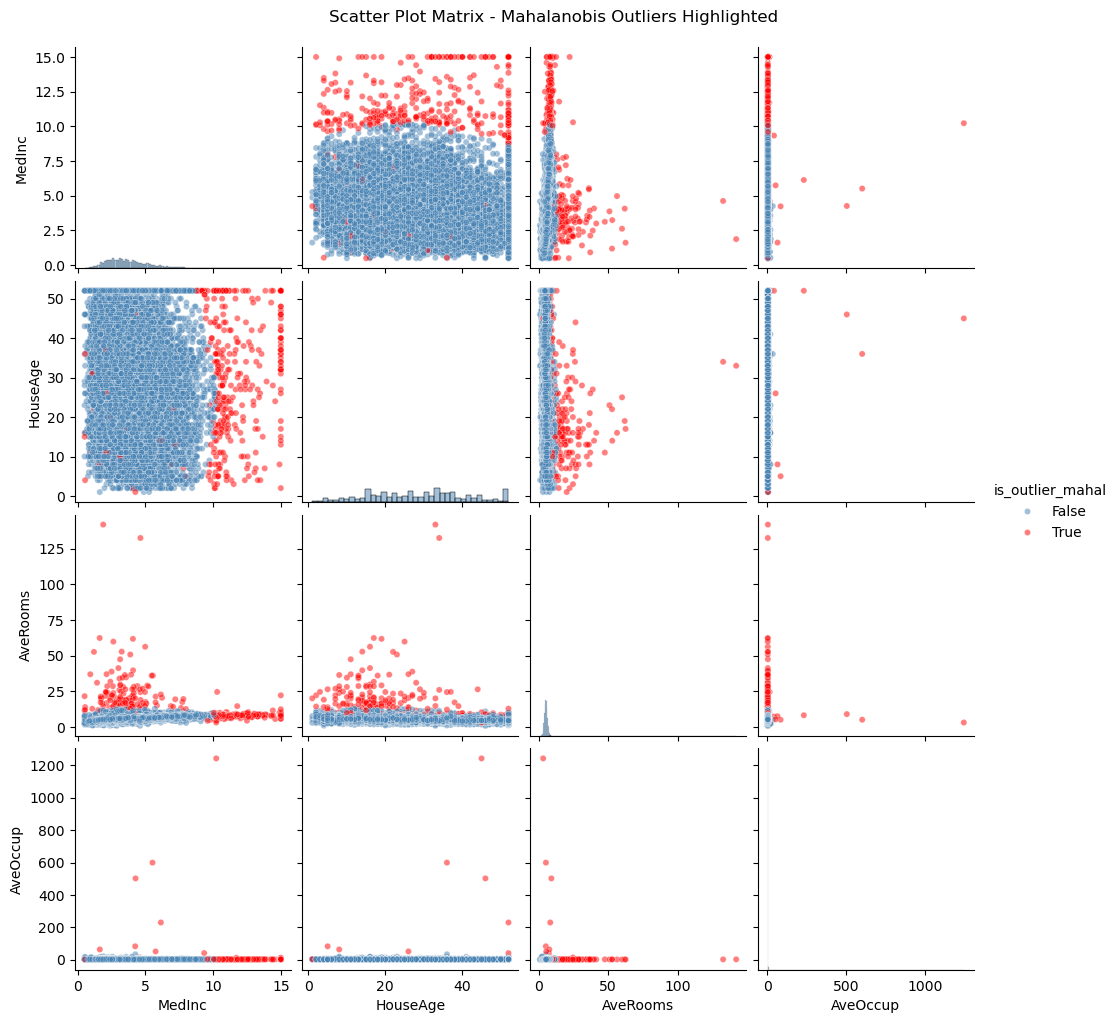

In [333]:
# EXERCISE 7: BONUS CHALLENGE - Multivariate Outlier Detection
# ------------------------------------------------------------

from scipy.stats import chi2

# ----- Step 1: Select features for multivariate analysis -----
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']
X = df[features].values

# ----- Step 2: Calculate Mahalanobis distance for each point -----
def mahalanobis_distance(X):
    mean_vec = np.mean(X, axis=0)
    cov_matrix = np.cov(X, rowvar=False)
    inv_cov_matrix = np.linalg.inv(cov_matrix)
    
    diff = X - mean_vec
    # Mahalanobis distance formula: sqrt((x-mean)^T * inv(cov) * (x-mean))
    md = np.sqrt(np.sum(diff @ inv_cov_matrix * diff, axis=1))
    return md

mahal_dist = mahalanobis_distance(X)

# ----- Step 3: Determine outlier threshold using Chi-squared distribution -----
# Mahalanobis distance squared follows a chi-squared distribution
# with degrees of freedom = number of features
dof = len(features)
threshold = chi2.ppf(0.975, dof)  # 97.5th percentile -> ~2.5% flagged as outliers
mahal_threshold = np.sqrt(threshold)  # since we computed sqrt earlier

# ----- Step 4: Identify outliers -----
outliers_mahal = np.where(mahal_dist > mahal_threshold)[0]
print(f"Mahalanobis outliers detected: {len(outliers_mahal)}")
print(f"Outlier percentage: {len(outliers_mahal)/len(df)*100:.2f}%")
print(f"Threshold (Mahalanobis distance): {mahal_threshold:.4f}")

# Add as a column for easy filtering/visualization
df['mahal_distance'] = mahal_dist
df['is_outlier_mahal'] = df.index.isin(outliers_mahal)

# ----- Step 5: Visualize using a scatter plot matrix -----
sns.pairplot(
    df,
    vars=features,
    hue='is_outlier_mahal',
    palette={False: 'steelblue', True: 'red'},
    plot_kws={'alpha': 0.5, 's': 20},
    diag_kind='hist'
)
plt.suptitle('Scatter Plot Matrix - Mahalanobis Outliers Highlighted', y=1.02)
plt.show()